In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma as gamma_func
from scipy.optimize import brentq
from scipy.stats import linregress
 
plt.rcParams.update({
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})
 
RNG = np.random.default_rng(seed=42)

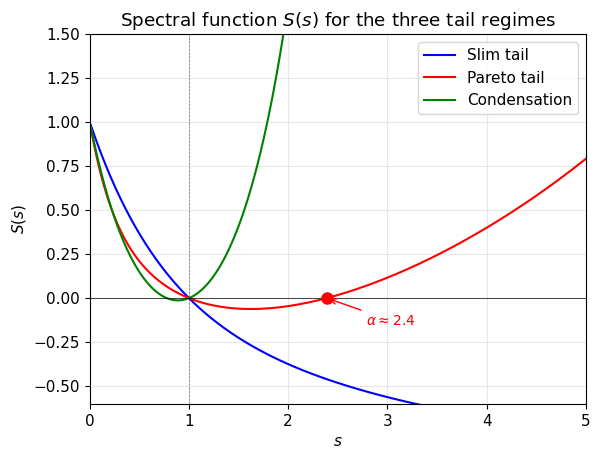

In [2]:
# ═══════════════════════════════════════════════════════════════
# S(s) schematic — three regimes
# ═══════════════════════════════════════════════════════════════


N_AGENTS = 50000       # number of agents
N_TRADES = 3000   # number of binary trades per simulation
SEED = 42

rng = np.random.default_rng(SEED)


def fig1_Ss_schematic():
    s = np.linspace(0.01, 5, 500)

    # Case 1: Slim tail — pointwise conservative, no risk
    lam = 0.5
    S_slim = ((1+lam)/2)**s + ((1-lam)/2)**s - 1

    # Case 2: Pareto tail — CPT Bernoulli, root visible around s ≈ 2.4
    lam2, mu2 = 0.3, 0.64
    S_pareto = 0.5 * (((1+lam2)/2 + mu2)**s + ((1+lam2)/2 - mu2)**s +
                       2*((1-lam2)/2)**s) - 1

    # Case 3: Condensation — general conservative-in-the-mean model
    S_cond = 0.1 * 5.0**s + 0.9 * 0.1**s + 0.41**s - 1

    fig, ax = plt.subplots()
    ax.plot(s, S_slim, 'b-', 
            label=r'Slim tail')
    ax.plot(s, S_pareto, 'r-', 
            label=r'Pareto tail')
    ax.plot(s, S_cond, 'g-', 
            label=r'Condensation')
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=1, color='k', linewidth=0.5, linestyle='--', alpha=0.5)

    # Mark the Pareto root
    S_func = lambda ss: 0.5*(((1+lam2)/2+mu2)**ss + ((1+lam2)/2-mu2)**ss +
                              2*((1-lam2)/2)**ss) - 1
    try:
        alpha_root = brentq(S_func, 1.01, 10)
        ax.plot(alpha_root, 0, 'ro', markersize=8, zorder=5)
        ax.annotate(rf'$\alpha \approx {alpha_root:.1f}$',
                    xy=(alpha_root, 0), xytext=(alpha_root + 0.4, -0.15),
                    fontsize=10, arrowprops=dict(arrowstyle='->', color='r'),
                    color='r')
    except:
        pass

    ax.set_xlabel(r'$s$')
    ax.set_ylabel(r'$S(s)$')
    ax.set_title(r'Spectral function $S(s)$ for the three tail regimes')
    ax.set_xlim(0, 5)
    ax.set_ylim(-0.6, 1.5)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()

fig1_Ss_schematic()

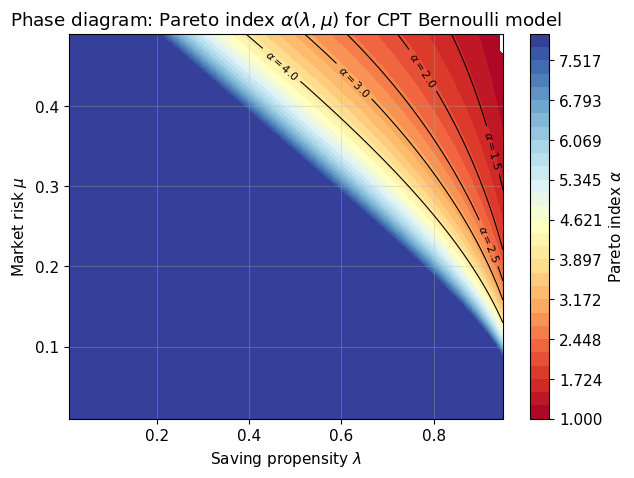

In [3]:
# ═══════════════════════════════════════════════════════════════
# Phase Diagram
# ═══════════════════════════════════════════════════════════════

def fig5_phase_diagram():
    lam_vals = np.linspace(0.01, 0.95, 150)
    mu_vals = np.linspace(0.01, 0.49, 150)
    alpha_grid = np.full((len(mu_vals), len(lam_vals)), np.nan)

    for i, mu in enumerate(mu_vals):
        for j, lam in enumerate(lam_vals):
            S_func = lambda ss, l=lam, m=mu: 0.5*(((1+l)/2+m)**ss + ((1+l)/2-m)**ss +
                                      2*((1-l)/2)**ss) - 1
            try:
                S_at_large = S_func(50)
                if S_at_large > 0:
                    alpha = brentq(S_func, 1.001, 50)
                    alpha_grid[i, j] = alpha
                else:
                    alpha_grid[i, j] = np.inf
            except:
                alpha_grid[i, j] = np.nan

    alpha_plot = np.clip(alpha_grid, 1, 8)
    alpha_plot[np.isinf(alpha_grid)] = 8

    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.contourf(lam_vals, mu_vals, alpha_plot,
                     levels=np.linspace(1, 8, 30), cmap='RdYlBu')
    cbar = fig.colorbar(im, ax=ax, label=r'Pareto index $\alpha$')

    cs = ax.contour(lam_vals, mu_vals, alpha_plot,
                    levels=[1.5, 2.0, 2.5, 3.0, 4.0], colors='k', linewidths=0.8)
    ax.clabel(cs, inline=True, fontsize=8, fmt=r'$\alpha=%.1f$')

    ax.set_xlabel(r'Saving propensity $\lambda$')
    ax.set_ylabel(r'Market risk $\mu$')
    ax.set_title(r'Phase diagram: Pareto index $\alpha(\lambda, \mu)$ for CPT Bernoulli model')
    plt.show()
fig5_phase_diagram()

In [4]:
# ═══════════════════════════════════════════════════════════════
# Functions for future use
# ═══════════════════════════════════════════════════════════════
 
def inverse_gamma_pdf(v, alpha, m=1.0):
    r = alpha - 1
    return (r * m)**alpha / gamma_func(alpha) * v**(-(1 + alpha)) * np.exp(-r * m / v)
 
 
def hill_estimator(wealth, tail_fraction=0.05):
    w = wealth[np.isfinite(wealth) & (wealth > 0)]
    w = np.sort(w)
    k = max(int(len(w) * tail_fraction), 10)
    top = w[-k:]
    threshold = w[-k]
    if threshold <= 0:
        return np.nan
    denom = np.sum(np.log(top / threshold))
    return k / denom if denom > 0 else np.nan
 
 
def spectral_S_cpt(s, lam, mu):
    return 0.5 * (((1+lam)/2 + mu)**s + ((1+lam)/2 - mu)**s) + ((1-lam)/2)**s - 1
 
 
def find_alpha_cpt(lam, mu):
    Sp = 0.5 * (
        ((1+lam)/2 + mu) * np.log((1+lam)/2 + mu)
        + ((1+lam)/2 - mu) * np.log((1+lam)/2 - mu)
    ) + ((1-lam)/2) * np.log((1-lam)/2)
    if mu <= (1 - lam) / 2:
        return np.inf
    if Sp >= 0:
        return np.nan
    try:
        return brentq(lambda s: spectral_S_cpt(s, lam, mu), 1.01, 50)
    except ValueError:
        return np.inf

In [5]:
# ═══════════════════════════════════════════════════════════════
# Simulation engines
# ═══════════════════════════════════════════════════════════════
 
def simulate_cpt_bernoulli(N, n_rounds, lam, mu):
    wealth = RNG.exponential(1.0, size=N)
    g = (1 - lam) / 2
    for _ in range(n_rounds):
        perm = RNG.permutation(N)
        h = N // 2
        ii, jj = perm[:h], perm[h:2*h]
        v, w = wealth[ii], wealth[jj]
        e1 = mu * (2 * RNG.integers(0, 2, size=h) - 1).astype(float)
        e2 = mu * (2 * RNG.integers(0, 2, size=h) - 1).astype(float)
        vn = ((1+lam)/2 + e1) * v + g * w
        wn = ((1+lam)/2 + e2) * w + g * v
        ok = (vn >= 0) & (wn >= 0)
        wealth[ii[ok]] = vn[ok]
        wealth[jj[ok]] = wn[ok]
    return wealth
 
 
def simulate_slanina(N, n_rounds, p, q, batch_frac=0.05):
    wealth = RNG.exponential(1.0, size=N)
    batch = max(int(N * batch_frac), 100)
    for r in range(n_rounds):
        indices = RNG.choice(N, size=2*batch, replace=False)
        ii, jj = indices[:batch], indices[batch:]
        v, w = wealth[ii], wealth[jj]
        wealth[ii] = p * v + q * w
        wealth[jj] = q * v + p * w
        m = np.mean(wealth)
        if m > 0 and np.isfinite(m):
            wealth /= m
    return wealth

Kinetic Wealth Distribution — Monte Carlo Simulations

[1/5] CPT Bernoulli: histograms vs theory...


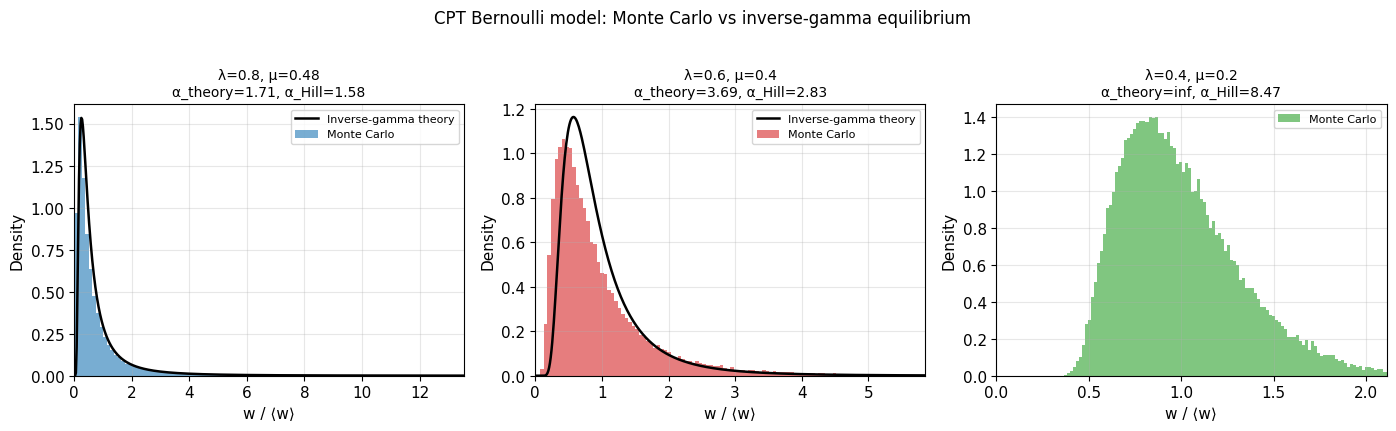

In [6]:
# ═══════════════════════════════════════════════════════════════
# CPT Bernoulli — histograms vs theory
# ═══════════════════════════════════════════════════════════════
 
 
print("\n[1/5] CPT Bernoulli: histograms vs theory...")
N = 50_000
ROUNDS = 3000
params = [
    (0.8, 0.48, "tab:blue"),    # α ≈ 1.71, very fat
    (0.6, 0.40, "tab:red"),     # α ≈ 3.42, moderate
    (0.4, 0.20, "tab:green"),   # α ≈ 7+, very slim
]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (lam, mu, col) in zip(axes, params):
    w = simulate_cpt_bernoulli(N, ROUNDS, lam, mu)
    mw = np.mean(w)
    at = find_alpha_cpt(lam, mu)
    ah = hill_estimator(w)
    wn = w / mw
    upper = np.percentile(wn, 99.5)
    vp = np.linspace(0.01, upper, 500)
    if np.isfinite(at):
        ax.plot(vp, inverse_gamma_pdf(vp, at), "k-", lw=1.8, label="Inverse-gamma theory")
    ax.hist(wn[wn < upper*1.1], bins=120, density=True, alpha=0.6,
            color=col, edgecolor="none", label="Monte Carlo")
    ax.set_title(f"λ={lam}, μ={mu}\nα_theory={at:.2f}, α_Hill={ah:.2f}", fontsize=10)
    ax.set_xlabel("w / ⟨w⟩")
    ax.set_ylabel("Density")
    ax.set_xlim(0, upper)
    ax.legend(fontsize=8)
fig.suptitle("CPT Bernoulli model: Monte Carlo vs inverse-gamma equilibrium",
             fontsize=12, y=1.02)
fig.tight_layout()
plt.show()


[2/5] Pareto index verification...
    λ=0.3, μ=0.455: α_th=6.94, α̂=3.23
    λ=0.3, μ=0.480: α_th=5.65, α̂=3.00
    λ=0.5, μ=0.380: α_th=5.65, α̂=3.24
    λ=0.5, μ=0.430: α_th=4.14, α̂=2.83
    λ=0.5, μ=0.480: α_th=3.26, α̂=2.37
    λ=0.6, μ=0.355: α_th=4.73, α̂=3.11
    λ=0.6, μ=0.417: α_th=3.40, α̂=2.47
    λ=0.6, μ=0.480: α_th=2.65, α̂=2.10
    λ=0.7, μ=0.255: α_th=6.79, α̂=4.06
    λ=0.7, μ=0.330: α_th=3.95, α̂=2.93
    λ=0.7, μ=0.405: α_th=2.79, α̂=2.25
    λ=0.7, μ=0.480: α_th=2.16, α̂=1.85
    λ=0.8, μ=0.217: α_th=5.72, α̂=3.85
    λ=0.8, μ=0.305: α_th=3.17, α̂=2.61
    λ=0.8, μ=0.392: α_th=2.21, α̂=2.00
    λ=0.8, μ=0.480: α_th=1.71, α̂=1.52


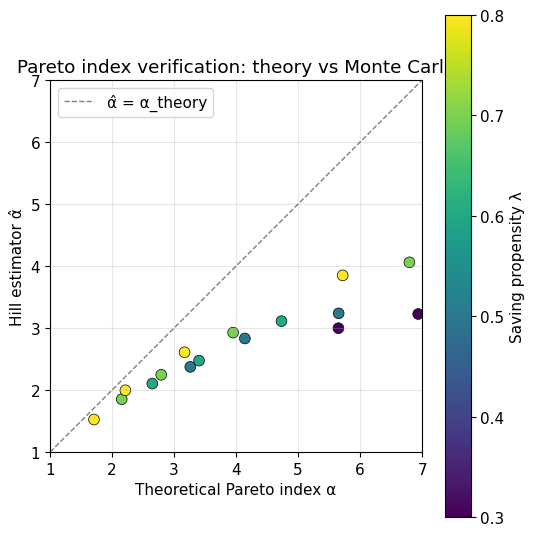

In [7]:
# ═══════════════════════════════════════════════════════════════
# Pareto index — theory vs Hill estimator
# ═══════════════════════════════════════════════════════════════
 
print("\n[2/5] Pareto index verification...")
results = []
for lam in [0.3, 0.5, 0.6, 0.7, 0.8]:
    mu_min = (1 - lam) / 2 + 0.03
    mu_max = min(0.48, (1 + lam) / 2 - 0.05)
    if mu_min >= mu_max:
        continue
    for mu in np.linspace(mu_min, mu_max, 5):
        at = find_alpha_cpt(lam, mu)
        if not np.isfinite(at) or at > 7:
            continue
        w = simulate_cpt_bernoulli(N, ROUNDS, lam, mu)
        ah = hill_estimator(w)
        results.append((lam, mu, at, ah))
        print(f"    λ={lam:.1f}, μ={mu:.3f}: α_th={at:.2f}, α̂={ah:.2f}")
R = np.array(results)
fig, ax = plt.subplots(figsize=(5.5, 5.5))
sc = ax.scatter(R[:, 2], R[:, 3], c=R[:, 0], cmap="viridis",
                s=60, edgecolors="k", linewidths=0.5)
ax.plot([1, 7], [1, 7], "k--", lw=1, alpha=0.5, label="α̂ = α_theory")
ax.set_xlabel("Theoretical Pareto index α")
ax.set_ylabel("Hill estimator α̂")
ax.set_title("Pareto index verification: theory vs Monte Carlo")
ax.legend()
fig.colorbar(sc, ax=ax, label="Saving propensity λ")
ax.set_xlim(1, 7)
ax.set_ylim(1, 7)
ax.set_aspect("equal")
fig.tight_layout()
plt.show()


[3/5] Slanina: exact self-similar profile...


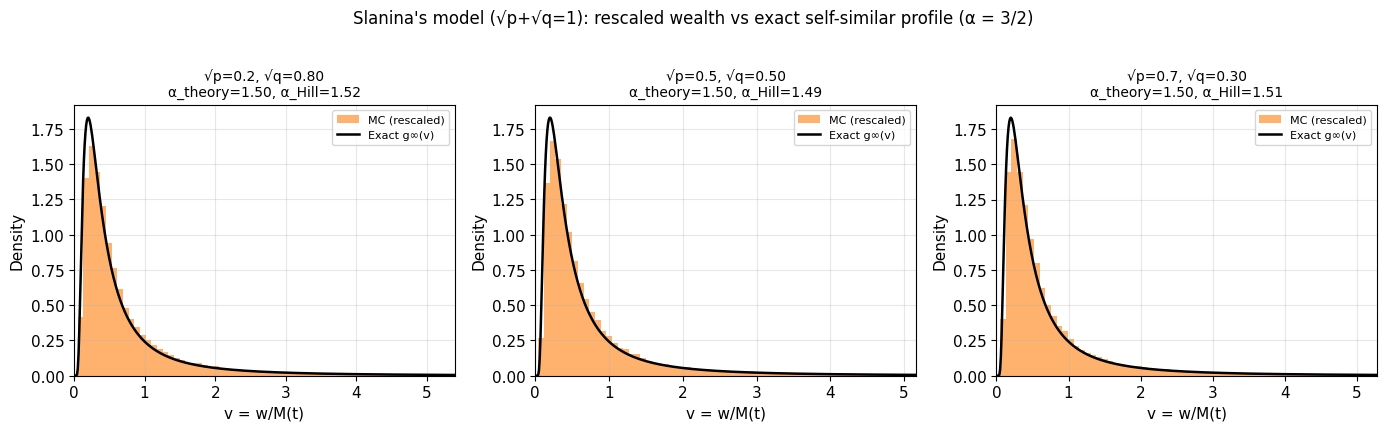

In [8]:
# ═══════════════════════════════════════════════════════════════
# Slanina — exact self-similar profile (α = 3/2)
# ═══════════════════════════════════════════════════════════════
 
print("\n[3/5] Slanina: exact self-similar profile...")
N_sl = 50_000
ROUNDS_sl = 3000
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, sp in zip(axes, [0.2, 0.50, 0.7]):
    sq = 1 - sp
    p, q = sp**2, sq**2
    wn = simulate_slanina(N_sl, ROUNDS_sl, p, q)
    wn = wn / np.mean(wn)
    ah = hill_estimator(wn)
    upper = np.percentile(wn, 98)
    vp = np.linspace(0.01, upper, 500)
    pdf_exact = (1 / np.sqrt(2 * np.pi)) * vp**(-5/2) * np.exp(-1 / (2 * vp))
    ax.hist(wn[wn < upper*1.2], bins=80, density=True, alpha=0.6,
            color="tab:orange", edgecolor="none", label="MC (rescaled)")
    ax.plot(vp, pdf_exact, "k-", lw=1.8, label="Exact g∞(v)")
    ax.set_title(f"√p={sp}, √q={sq:.2f}\nα_theory=1.50, α_Hill={ah:.2f}", fontsize=10)
    ax.set_xlabel("v = w/M(t)")
    ax.set_ylabel("Density")
    ax.set_xlim(0, upper)
    ax.legend(fontsize=8)
fig.suptitle("Slanina's model (√p+√q=1): rescaled wealth vs exact self-similar profile (α = 3/2)",
             fontsize=12, y=1.02)
fig.tight_layout()
plt.show()


[4/5] Taxed CPT: effect of taxation...


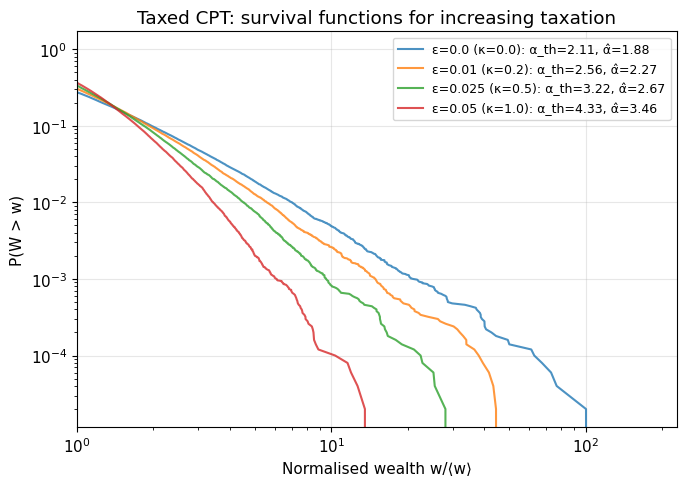

In [9]:
# ═══════════════════════════════════════════════════════════════
# Taxed CPT 
# ═══════════════════════════════════════════════════════════════
 
print("\n[4/5] Taxed CPT: effect of taxation...")
N_tax = 50_000
ROUNDS_tax = 3000
gamma_t = 0.05
sigma = 0.30
chi = 1.0
lam_eff = sigma**2 / gamma_t
 
fig, ax = plt.subplots(figsize=(7, 5))
for eps, col in zip([0.0, 0.01, 0.025, 0.05],
                    ["tab:blue", "tab:orange", "tab:green", "tab:red"]):
    kappa = eps / gamma_t
    at = 1 + 2 * (1 + kappa * (chi + 1)) / lam_eff
    
    wealth = RNG.exponential(1.0, size=N_tax)
    for rnd in range(ROUNDS_tax):
        perm = RNG.permutation(N_tax)
        h = N_tax // 2
        ii, jj = perm[:h], perm[h:2*h]
        v, w = wealth[ii], wealth[jj]
        e1 = RNG.normal(0, sigma, size=h)
        e2 = RNG.normal(0, sigma, size=h)
        vn = (1 - gamma_t - eps + e1) * v + gamma_t * w
        wn = gamma_t * v + (1 - gamma_t - eps + e2) * w
        ok = (vn >= 0) & (wn >= 0)
        wealth[ii[ok]] = vn[ok]
        wealth[jj[ok]] = wn[ok]
        # Apply redistribution EVERY round
        if eps > 0:
            m = np.mean(wealth)
            wealth += eps * (-(chi * wealth) + (chi + 1) * m)
            wealth = np.maximum(wealth, 0)
    
    w_norm = wealth / np.mean(wealth)
    w_sorted = np.sort(w_norm)
    surv = 1 - np.arange(1, len(w_sorted) + 1) / len(w_sorted)
    ah = hill_estimator(w_norm)
    ax.loglog(w_sorted, surv, "-", lw=1.5, color=col, alpha=0.8,
              label=f"ε={eps} (κ={kappa:.1f}): α_th={at:.2f}, α̂={ah:.2f}")

ax.set_xlabel("Normalised wealth w/⟨w⟩")
ax.set_ylabel("P(W > w)")
ax.set_xlim(1, None)
ax.set_title("Taxed CPT: survival functions for increasing taxation")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


[5/5] Log-log tail plot...


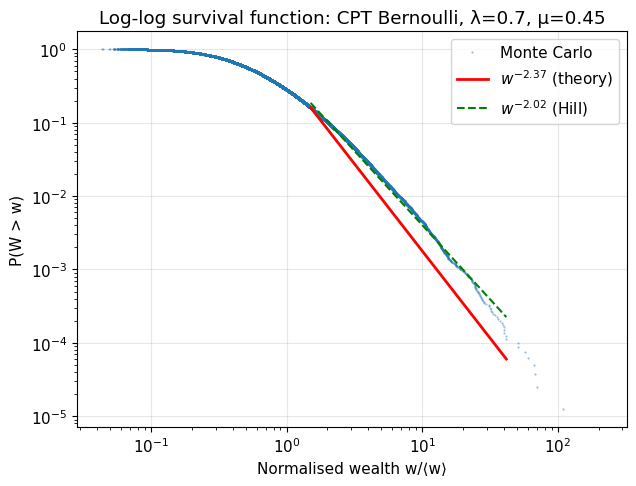

In [10]:
# ═══════════════════════════════════════════════════════════════
# Log-log survival function
# ═══════════════════════════════════════════════════════════════
 
print("\n[5/5] Log-log tail plot...")
N_log = 80_000
ROUNDS_log = 3000
lam, mu = 0.7, 0.45
wealth = simulate_cpt_bernoulli(N_log, ROUNDS_log, lam, mu)
mw = np.mean(wealth)
wn = np.sort(wealth / mw)
surv = 1 - np.arange(1, N_log + 1) / N_log
at = find_alpha_cpt(lam, mu)
ah = hill_estimator(wn)
 
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.loglog(wn, surv, ".", markersize=1, alpha=0.5, color="tab:blue", label="Monte Carlo")
wt = np.logspace(np.log10(1.5), np.log10(wn[-10]), 100)
idx = np.argmin(np.abs(wn - 1.5))
Cf = surv[idx] * 1.5**at
ax.loglog(wt, Cf * wt**(-at), "r-", lw=2, label=f"$w^{{-{at:.2f}}}$ (theory)")
ax.loglog(wt, Cf * wt**(-ah), "g--", lw=1.5, label=f"$w^{{-{ah:.2f}}}$ (Hill)")
ax.set_xlabel("Normalised wealth w/⟨w⟩")
ax.set_ylabel("P(W > w)")
ax.set_title(f"Log-log survival function: CPT Bernoulli, λ={lam}, μ={mu}")
ax.legend()
fig.tight_layout()
plt.show()

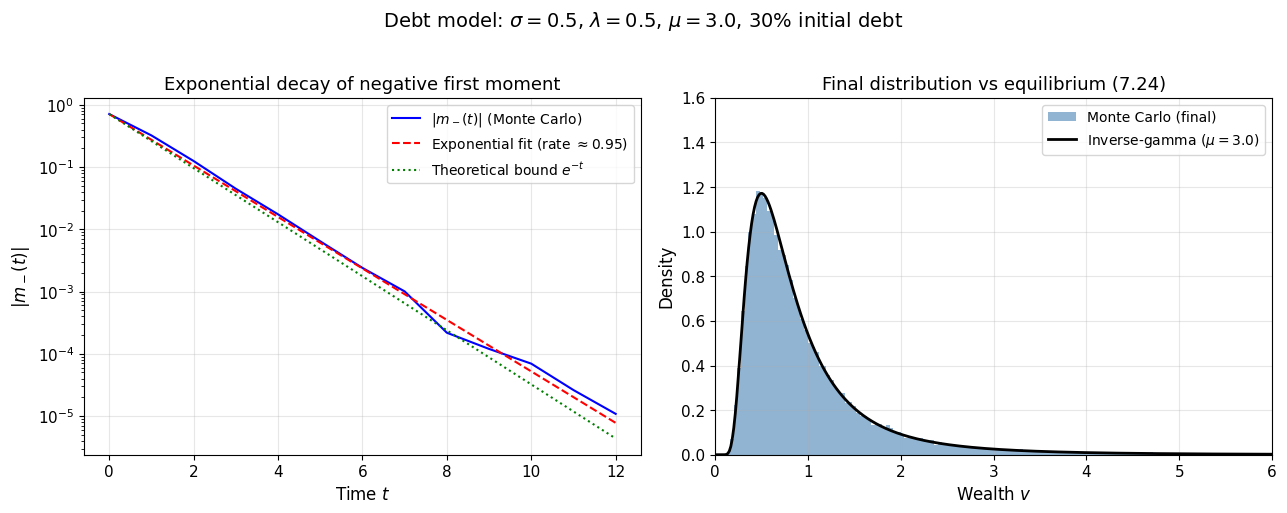

mu = 3.0, final neg fraction = 0.000000


In [11]:
# ═══════════════════════════════════════════════════════════════
# Debt model simulation
# ═══════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma as gamma_func

# Parameters
N = 50_000
sigma = 0.5
lam = 0.5
mu_param = 1 + 2*lam/sigma   # = 3.0
dt = 0.005
steps_per_round = 20
T_rounds = 3000

np.random.seed(42)

# Initialise: 70% exponential(mean=1.5), 30% negative uniform[-3, 0]
n_pos = int(0.7 * N)
n_neg = N - n_pos
v_pos = np.random.exponential(1.5, size=n_pos)
v_neg = np.random.uniform(-3.0, 0.0, size=n_neg)
v = np.concatenate([v_pos, v_neg])
v = v / np.mean(v)  # rescale to mean 1

# Storage
record_every = 10
m_neg_list = []
time_list = []

for r in range(T_rounds):
    for _ in range(steps_per_round):
        dW = np.sqrt(dt) * np.random.randn(N)
        v = v + lam * (1.0 - v) * dt + np.sqrt(sigma) * v * dW

    if r % record_every == 0:
        neg_mask = v < 0
        m_neg_list.append(np.abs(np.sum(v[neg_mask]) / N))
        time_list.append(r * dt * steps_per_round)

time_arr = np.array(time_list)
m_neg_arr = np.array(m_neg_list)

# Figure
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: decay of |m-(t)|
ax = axes[0]
valid = m_neg_arr > 1e-14
if np.sum(valid) > 5:
    ax.semilogy(time_arr[valid], m_neg_arr[valid], 'b-', linewidth=1.5, label=r'$|m_-(t)|$ (Monte Carlo)')
    # Fit exponential
    t_v = time_arr[valid]
    m_v = m_neg_arr[valid]
    use = m_v > 1e-10
    if np.sum(use) > 5:
        t_u = t_v[use]
        m_u = m_v[use]
        coeffs = np.polyfit(t_u[:len(t_u)//2], np.log(m_u[:len(m_u)//2]), 1)
        rate = -coeffs[0]
        ax.semilogy(t_v, m_v[0] * np.exp(-rate * t_v),
                     'r--', linewidth=1.5, label=f'Exponential fit (rate $\\approx {rate:.2f}$)')
    ax.semilogy(t_v, m_v[0] * np.exp(-t_v), 'g:', linewidth=1.5, label=r'Theoretical bound $e^{-t}$')

ax.set_xlabel(r'Time $t$', fontsize=12)
ax.set_ylabel(r'$|m_-(t)|$', fontsize=12)
ax.set_title(r'Exponential decay of negative first moment', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Right: final histogram
ax2 = axes[1]
v_pos_final = v[v > 0.005]
vgrid = np.linspace(0.01, 8, 500)
C_norm = (mu_param - 1)**mu_param / gamma_func(mu_param)
f_theory = C_norm * vgrid**(-(1 + mu_param)) * np.exp(-(mu_param - 1) / vgrid)

ax2.hist(v_pos_final, bins=200, range=(0, 8), density=True, alpha=0.6, color='steelblue', label='Monte Carlo (final)')
ax2.plot(vgrid, f_theory, 'k-', linewidth=2, label=f'Inverse-gamma ($\\mu={mu_param:.1f}$)')
ax2.set_xlabel(r'Wealth $v$', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title(r'Final distribution vs equilibrium (7.24)', fontsize=13)
ax2.legend(fontsize=10)
ax2.set_ylim(0, 1.6)
ax2.set_xlim(0, 6)

fig.suptitle(f'Debt model: $\\sigma={sigma}$, $\\lambda={lam}$, $\\mu={mu_param:.1f}$, 30% initial debt',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print(f"mu = {mu_param}, final neg fraction = {np.mean(v<0):.6f}")